#                                                                **Descriptive Analysis**

## ***Q1. What is the demographic profile of the hospitalized heart-failure population?***

#### *Reasoning : Patients belongs to each age group and how many are male or female. It also gives us a starting point for comparing other results, such as heart failure severity, across these groups.*

In [94]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

Age distribution:
age_category
21-29       4
29-39      12
39-49      56
49-59     106
59-69     368
69-79     715
79-89     646
89-110    101
Name: count, dtype: int64

Gender distribution:
gender
Female    1163
Male       845
Name: count, dtype: int64


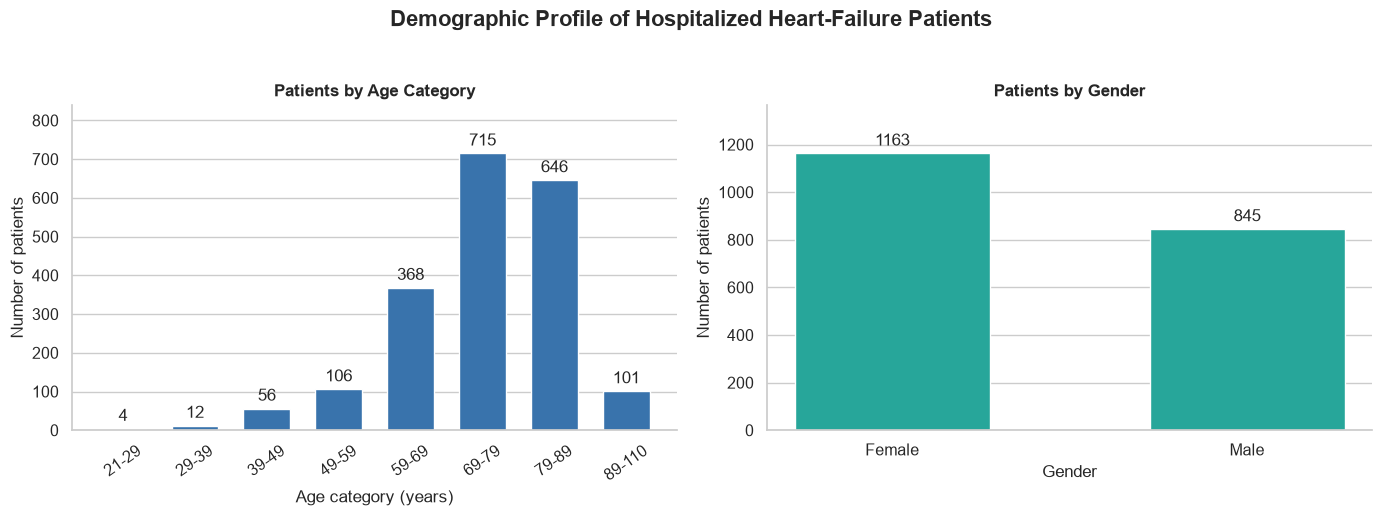

In [95]:
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
chart_df=hf_df.copy()
#############################
age_counts = chart_df["age_category"].dropna().value_counts()
age_order = sorted(age_counts.index, key=lambda x: int(x.split("-")[0].strip()))
age_counts = age_counts.reindex(age_order)

gender_counts = chart_df["gender"].dropna().value_counts()

print("Age distribution:")
print(age_counts)

print("\nGender distribution:")
print(gender_counts)

# Chart style
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Demographic Profile of Hospitalized Heart-Failure Patients",
    fontsize=16, fontweight="bold", y=1.03
)

# Age categories
age_bars = axes[0].bar(
    age_counts.index, age_counts.values,
    color="#3973AC", width=0.65
)
axes[0].set_title("Patients by Age Category", fontweight="bold")
axes[0].set_xlabel("Age category (years)")
axes[0].set_ylabel("Number of patients")
axes[0].tick_params(axis="x", rotation=35)
axes[0].bar_label(age_bars, padding=3)

# Gender
gender_bars = axes[1].bar(
    gender_counts.index, gender_counts.values,
    color="#27A69A", width=0.55
)
axes[1].set_title("Patients by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of patients")
axes[1].bar_label(gender_bars, padding=3)

# Finishing touches
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.show()

### ***Q2.What is the distribution of BMI among patients?***

#### *Reasoning: This shows the BMI values are common among the patients and whether some patients have much lower or higher BMI than most others.*

BMI summary statistics:
count    1969.00
mean       21.41
std         3.73
min        15.07
25%        18.67
50%        20.81
75%        23.44
max        39.11
Name: bmi, dtype: float64

BMI category distribution:
bmi
Underweight     476
Normal         1163
Overweight      263
Obese            61
Very Obese        6
Name: count, dtype: int64


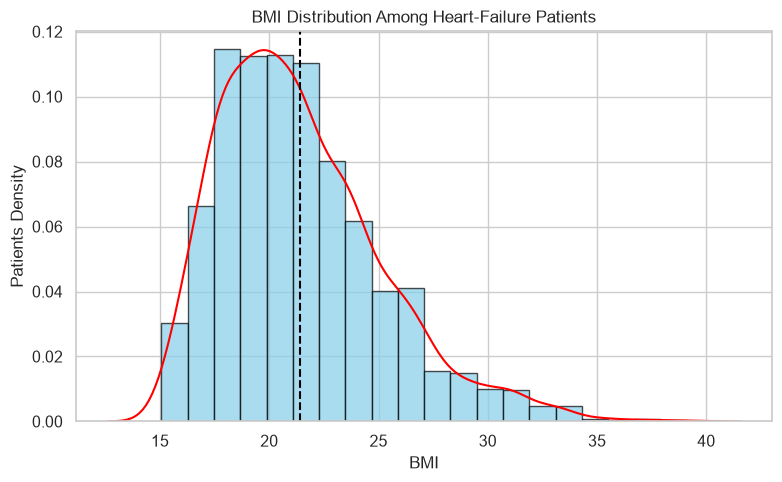

In [96]:

# BMI analysis
bmi_series = hf_df["bmi"].dropna()

# Summary statistics
print("BMI summary statistics:")
print(bmi_series.describe().round(2))

# BMI category breakdown
bmi_categories = pd.cut(
    bmi_series,
    bins=[0, 18.5, 24.9, 29.9, 34.9, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese", "Very Obese"]
)

category_counts = bmi_categories.value_counts().sort_index()
print("\nBMI category distribution:")
print(category_counts)

# Visualization
plt.figure(figsize=(8, 5))
plt.hist(bmi_series, bins=20, density=True, alpha=0.7, color="skyblue", edgecolor="black")
sns.kdeplot(bmi_series, color="red")
plt.axvline(bmi_series.mean(), color="black", linestyle="--", linewidth=1.5)

plt.title("BMI Distribution Among Heart-Failure Patients")
plt.xlabel("BMI")
plt.ylabel("Patients Density")
plt.tight_layout()
plt.show()

### ***Q3.Which existing health conditions are most common?***




#### *Reasoning: This helps us to see which health conditions patients already had and which ones appear most often in this group.*

mod_severe_ckd               23.6
diabetes                     23.2
copd                         11.6
cerebrovascular_disease       7.5
dementia                      5.7
liver_disease                 4.2
peptic_ulcer_disease          2.2
solid_tumor                   1.9
hemiplegia                    0.6
connective_tissue_disease     0.2
aids                          0.2
malignant_lymphoma            0.0
leukemia                      0.0
dtype: float64


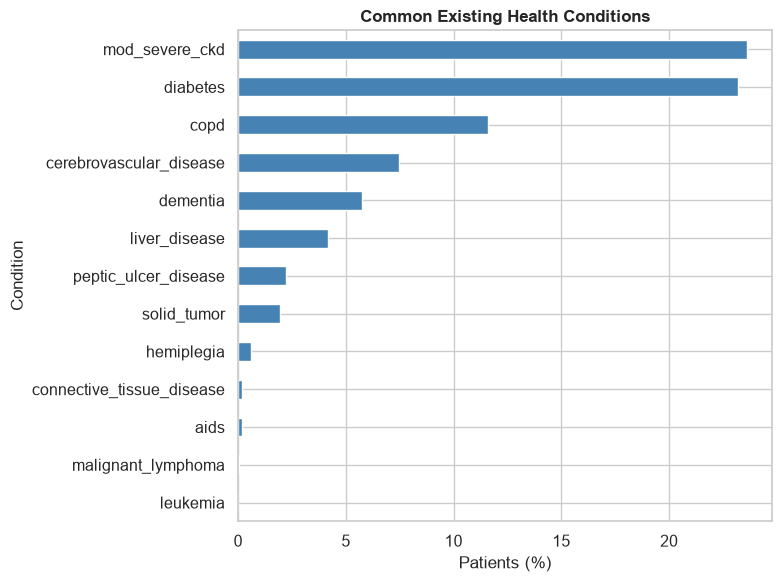

In [97]:
# Select comorbidity columns
conditions = [
    "cerebrovascular_disease", "dementia", "copd", "connective_tissue_disease",
    "peptic_ulcer_disease", "diabetes", "mod_severe_ckd", "hemiplegia",
    "leukemia", "malignant_lymphoma", "solid_tumor", "liver_disease", "aids"
]

cond_df = hf_df[conditions].fillna(0).astype(int)
percent = (cond_df.mean() * 100).sort_values(ascending=False)

print(percent.round(1))
plt.figure(figsize=(8, 6))
percent.plot(kind="barh", color="steelblue")
plt.title("Common Existing Health Conditions", fontsize=12, fontweight="bold")
plt.xlabel("Patients (%)")
plt.ylabel("Condition")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



### ***Q4.How are patients distributed across heart failure types or severity categories?***

#### *Reasoning: This shows how many patients fall into each heart failure type or severity group. It helps us understand whether most patients have milder or more severe heart failure.*

heart_failure_type
both     1480
left      477
right      51
Name: count, dtype: int64


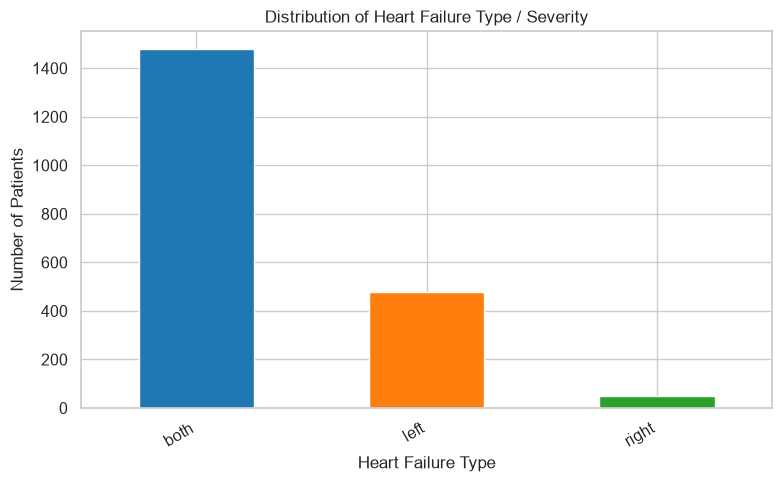

In [98]:



if "heart_failure_type" in hf_df.columns:
    severity_col = "heart_failure_type"
elif "nyha_cardiac_function_classification" in hf_df.columns:
    severity_col = "nyha_cardiac_function_classification"
elif "killip_grade" in hf_df.columns:
    severity_col = "killip_grade"
else:
    raise ValueError("No type/severity column found in the dataset.")

counts = hf_df[severity_col].dropna().astype(str).str.strip().value_counts()

print(counts)

# Bar chart with different colors
plt.figure(figsize=(8, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

counts.plot(kind="bar", color=colors[:len(counts)])
plt.title("Distribution of Heart Failure Type / Severity")
plt.xlabel(severity_col.replace("_", " ").title())
plt.ylabel("Number of Patients")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### ***Q5.Which cardiac complications are most common?***

#### *Reasoning : This helps us see which heart-related complications patients experienced most often*

congestive_heart_failure       93.2
myocardial_infarction           7.1
peripheral_vascular_disease     5.0
dtype: float64


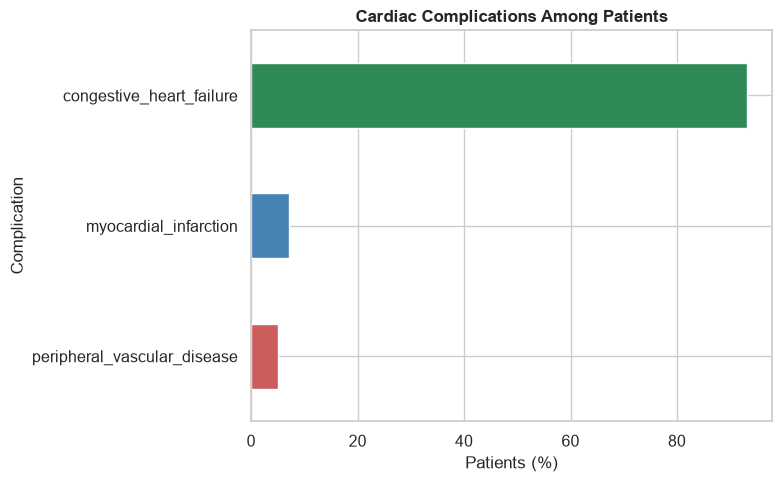

In [99]:
# Cardiac complication columns
complications = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

# Keep only relevant columns
comp_df = hf_df[complications].fillna(0).astype(int)

# Percentage of patients with each complication
percent = (comp_df.mean() * 100).sort_values(ascending=False)

print(percent.round(1))

# Horizontal bar chart
plt.figure(figsize=(8, 5))
percent.plot(kind="barh", color=["#2E8B57", "#4682B4", "#CD5C5C"])
plt.title("Cardiac Complications Among Patients", fontsize=12, fontweight="bold")
plt.xlabel("Patients (%)")
plt.ylabel("Complication")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### ***Q6.What is the distribution of key laboratory measurements?***

#### *Reasoning : This helps us understand the typical range and variability of key laboratory values in hospitalized heart-failure patients. It highlights whether most patients have normal or abnormal measurements, and shows extreme values that a simple average would hide.*

        sodium  potassium  hemoglobin
count  1974.00    1974.00     1974.00
mean    138.24       3.98      115.07
std       4.91       0.69       24.54
min     107.50       1.67       29.00
25%     136.00       3.52      101.00
50%     139.00       3.88      117.00
75%     141.30       4.33      131.00
max     159.00       7.29      200.00


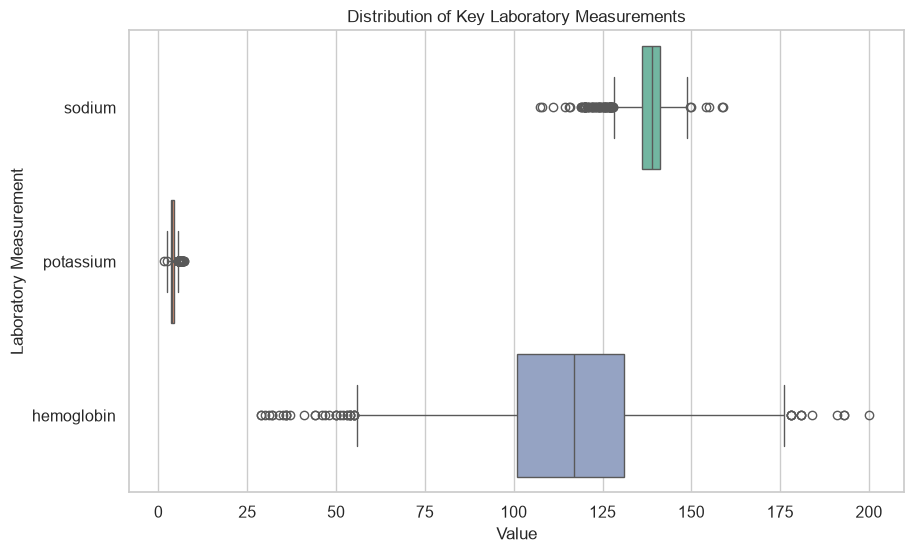

In [100]:
# Select key lab variables available in the dataset
lab_cols = ["sodium", "potassium", "hemoglobin"]
lab_cols = [c for c in lab_cols if c in hf_df.columns]

lab_df = hf_df[lab_cols].dropna()

# Summary stats
print(lab_df.describe().round(2))

# Boxplot for each lab measurement
plt.figure(figsize=(10, 6))
sns.boxplot(data=lab_df, orient="h", palette="Set2")
plt.title("Distribution of Key Laboratory Measurements")
plt.xlabel("Value")
plt.ylabel("Laboratory Measurement")
plt.show()

### ***Q13.Which medications were prescribed most often?***




#### *Reasoning: This identifies the medications that occurred most frequently in the drugs_list column, helping us understand the most commonly prescribed treatment patterns among heart-failure patients.*

Top prescribed medications:
drugs_list
spironolactone tablet                               1833
furosemide injection                                1718
furosemide tablet                                   1641
meglumine adenosine cyclophosphate for injection    1114
deslanoside injection                               1015
digoxin tablet                                       998
aspirin enteric-coated tablet                        958
atorvastatin calcium tablet                          822
milrinone injection                                  707
sulfotanshinone sodium injection                     570
Name: count, dtype: int64


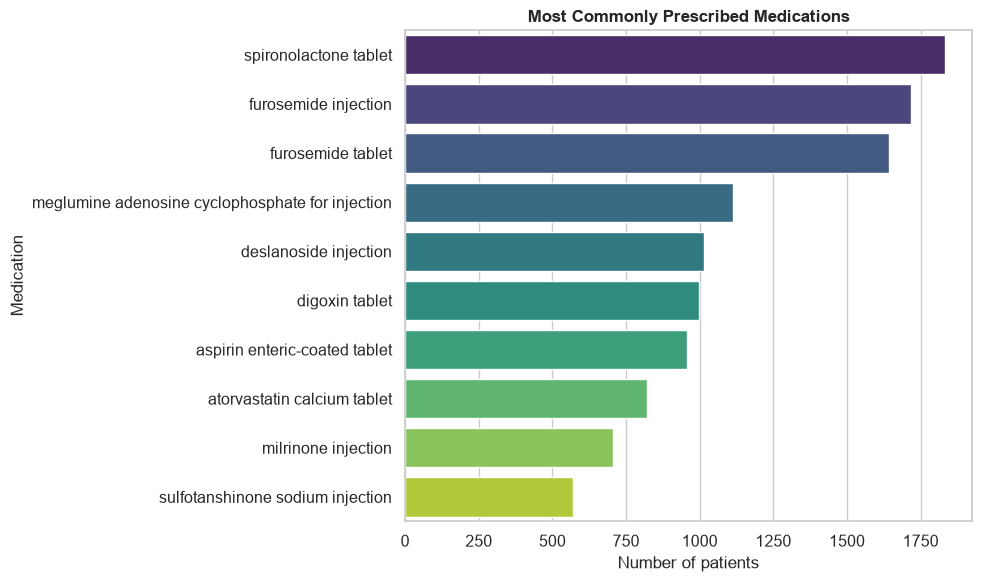

In [101]:
# Count individual medications from the drugs_list field
med_counts = (
    hf_df["drugs_list"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
    .loc[lambda x: x != ""]
    .value_counts()
)

top_meds = med_counts.head(10)

print("Top prescribed medications:")
print(top_meds)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_meds.values,
    y=top_meds.index,
    hue=top_meds.index,
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title("Most Commonly Prescribed Medications", fontsize=12, fontweight="bold")
plt.xlabel("Number of patients")
plt.ylabel("Medication")
plt.tight_layout()
plt.show()